In [1]:
import sys
ROOT = 'C:\\Mega\\trunk\\master-thesis\\'

sys.path.append(f'{ROOT}models\\survae_flows')
sys.path.append(f'{ROOT}models\\survae_flows\\experiments\\image')

%reload_ext autoreload

DEBUG = True
BATCH_COUNT = 200
if DEBUG:
    print('##########################')
    print('DEBUG Mode On!')
    print('##########################')

##########################
DEBUG Mode On!
##########################


In [2]:
import os
import torch
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import clear_output

%load_ext autoreload
%autoreload

# Data
from data.data_master import get_data, get_data_id, add_data_args

# Model
from model.model_master import get_master_model, get_master_model_id, add_model_args
from survae.utils.loss import loglik_bpd_per_sample #, elbo_bpd,%autoreload


# Master Extension Modules
from master_extension.remove_unwanted_classes import RemoveUnwantedClasses
from master_extension import config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'get_master_model' from 'model.model_master' (C:\Mega\trunk\master-thesis\models\survae_flows\experiments\image\model\model_master.py)

In [ ]:
DEVICE = 'cuda'
CLASS_COUNT = 10

Benutzt wird ein SurVAE Model für MNIST<br>
Training beendet nach:<br>
<br>
Training. Epoch: 140/500, Datapoint: 5792/5923, Bits/dim: 1.497 Time 127s<br>
Evaluating. Epoch: 140/500, Datapoint: 10000/10000, Bits/dim: 1.425<br>
----------------------------

In [ ]:
#model_checkpoint_path = 'C:/Mega/trunk/master-thesis/checkpoints/survae/13.04.first_run/checkpoint.pt'
#model_path = 'C:/Mega/trunk/master-thesis/models/survae_flows/experiments/image/log/mnist_8bit/pool_flow/expdecay/nonpool/'
#model_parameter_path = model_path + 'model_parameter/'

#model_path = 'C:/Mega/trunk/master-thesis/checkpoints/survae/17.4._full_trained_aug_max/'
model_path = 'C:/Mega/trunk/master-thesis/checkpoints/survae/19.4._fully_aug_max_cls_1/'
    
model_checkpoint_path = model_path + 'checkpoint.pt'
model_parameter_path = model_path + 'model_parameter/'

print(model_checkpoint_path)
print(model_parameter_path)

Load Config

In [ ]:

with open(model_parameter_path + 'args', 'rb') as f:
    args = pickle.load(f)
    
with open(model_parameter_path + 'data_shape', 'rb') as f:
    data_shape = pickle.load(f)

args.batch_size = 128

Load Model

In [ ]:
#model = get_model(args, data_shape=data_shape)
model = get_master_model(args, data_shape=data_shape)

#print('LOADED FROM check_safe!!!')
#check_path = os.path.join(model_path, 'check_safe', 'checkpoint.pt')

checkpoint = torch.load(model_checkpoint_path)

print('Load weights from')
print(model_checkpoint_path)
model.load_state_dict(checkpoint['model'])
_ = model.to(DEVICE)

Load Data 

In [ ]:
%autoreload

args.data_path = 'C:/Mega/trunk/master-thesis/datasets/'
config.REMOVE_UNWANTED_MAIN_TRAIN_CLS = True
config.REMOVE_UNWANTED_TEST_CLASS = True

train_loaders = []
eval_loaders = []
for c in range(CLASS_COUNT):
    filter_ = lambda targets: targets == c
    RemoveUnwantedClasses().set_filter(filter_)
    
    train_loader, eval_loader, data_shape = get_data(args)
    train_loaders.append(train_loader)
    eval_loaders.append(eval_loader)

    print(f'Eval samples of class {c}: {len(eval_loader.dataset.data)}')

TOTAL_DIMENSIONS = np.prod(data_shape)   

print('Data loaded')
print('Training Sample Count:')
print(len(train_loaders[0].dataset.data))
print('Eval Sample Count:')
print(len(eval_loader.dataset.data))

In [ ]:
def get_label(c, val):
    if c == -1:
        c = '!= 0'
    return f'{c} Total Loss: {val:.2f}'

In [ ]:
def eval_data(model, loader):
    model.eval()

    all_losses = []
    with torch.no_grad():
        loss_sum = 0.0
        loss_count = 0

        for i, x in enumerate(tqdm(loader)):
            x = x.to(DEVICE)
            #loss = elbo_bpd(model, x)
            loss_gpu = loglik_bpd_per_sample(model, x, TOTAL_DIMENSIONS)
            #print(loss_gpu)
            loss = -loss_gpu.sum().detach().cpu().item()
            loss_sum += loss
            loss_count += args.batch_size
            all_losses.append(loss_gpu.detach())
            
            if DEBUG and i >= BATCH_COUNT: break
    
    all_losses_gpu = torch.cat(all_losses)
    all_losses = all_losses_gpu.cpu().detach().numpy()
    return all_losses, all_losses_gpu.mean()

def eval_class(loaders, cls, model):
    #idx = loader.dataset.targets == cls
    #loader.dataset = loader.dataset.data[idx]
    #class_images = eval_loader.dataset.data[idx].to(DEVICE)

    print(f'Eval for Class: {cls}')
    evaled_ones = eval_data(model, loaders[cls])
    return evaled_ones

def eval_all_but_cls(loaders, cls, model):
    #idx = dataset.targets != cls
    #class_images = eval_loader.dataset.data[idx].to(DEVICE)

    print(f'Eval for all but: {cls}')
    evaled_ones = eval_data(model, loaders)
    return evaled_ones
    

In [ ]:
#np.random.normal(mu, sigma, 1000)

In [ ]:
BATCH_COUNT = 4

evaled_zeros = eval_class(eval_loaders, 0, model)
evaled_ones = eval_class(eval_loaders, 1, model)
evaled_eight = eval_class(eval_loaders, 8, model)
#evaled_all = eval_all_but_cls(eval_loaders, 0, model)

clear_output()
print('Done Evaluating')

#selection = [(0, evaled_zeros), (1, evaled_ones), (8, evaled_eight), (-1, evaled_all)]
selection = [(0, evaled_zeros), (1, evaled_ones), (8, evaled_eight)]

This is how the log likelihood is computed <br>
-model.log_prob(x).sum() / (math.log(2) * x.shape.numel()) <br>
but we negate ("-") again

In [ ]:
def filter_outliers(array):
    idx = array > -2
    return array[idx]

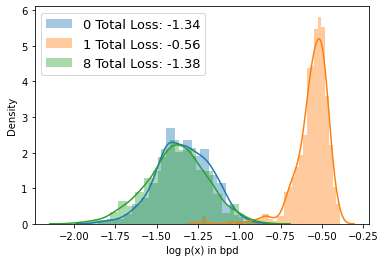

In [22]:
for c, res in selection:
    showable = filter_outliers(res[0])
    sns.distplot(showable, label=get_label(c, res[1]))

plt.xlabel('log p(x) in bpd')
plt.legend(fontsize=13)
clear_output()

Not deprecated plot function. 
(This is the same plot from a different plot function)

In [ ]:
#sns.histplot(evaled_all[0], label="!=0", kde=True, color='y', stat='density')
sns.histplot(evaled_zeros[0], label="0", kde=True, color='b', stat='density')
sns.histplot(evaled_ones[0], label="1", kde=True, color='g', alpha=0.5, stat='density')
sns.histplot(evaled_eight[0], label="8", kde=True, color='r', alpha=0.5, stat='density')


plt.xlim(right=0)
plt.xlabel('log p(x) in bpd')
_=plt.legend(fontsize=13)

In [18]:
BATCH_COUNT = 50
loss_of_all_classes = []
for c in range(0, 10):
    res = eval_class(eval_loaders, c, model)
    loss_of_all_classes.append((c, res))
    
clear_output()
print('Done')

Done


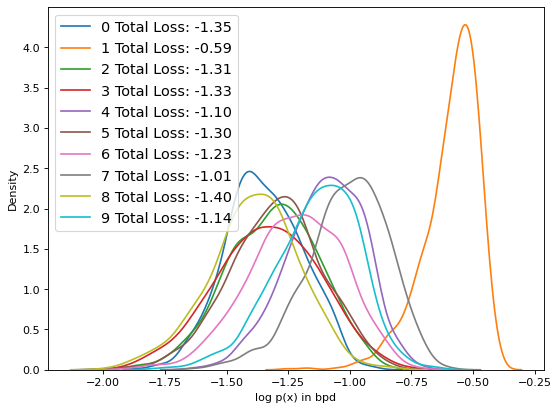

In [23]:
plt.figure(figsize=(8, 6), dpi=80)

for c, res in loss_of_all_classes:
    losses, val = res[0], res[1]
    hist_kws = {"linewidth": 10} if c == 0 else None
    showable = filter_outliers(losses)
    sns.distplot(showable, label=get_label(c, val), hist_kws=hist_kws, hist=False)

#sns.distplot(alls, label="!= 0", hist=False)
clear_output()

plt.xlabel('log p(x) in bpd')
_=plt.legend(fontsize=13)